# Transfert sur photos réelles françaises — la phase-leçon (Phase 3)

La baseline affiche rappel 0,876 / précision 0,904 (seuil 0,3) sur la **validation interne** — 87 images du même dataset Kaggle international que l'entraînement. Ce carnet mesure ce que le modèle vaut sur le **domaine cible réel** : 87 photos personnelles de l'utilisateur (iPhone, type annonce leboncoin, plaques françaises), annotées **en aveugle** (95 boîtes vérité, 4 photos sans plaque, protocole `annoter_plaques.py`).

Pourquoi « phase-leçon » : l'arc précédent (dégâts) affichait de bonnes métriques internes et un ROC de 0,509 — pile ou face — sur le domaine réel. C'est ici que ce pilier se juge.

**Métriques** :
- rappel / précision à IoU ≥ 0,5 et ≥ 0,3 (une boîte un peu décalée qui couvre l'essentiel de la plaque reste utile pour flouter — d'où le seuil IoU assoupli en seconde lecture) ;
- **couverture après marge** : fraction de chaque plaque vérité couverte par l'union des boîtes prédites élargies de 15 % (la marge qu'applique `flouter.py`). C'est **la métrique RGPD réelle** : une plaque couverte à 100 % est illisible même si l'IoU est moyen ;
- courbe rappel/seuil de confiance → choix du seuil bas de floutage (ADR DL 0002).

In [1]:
import sys

sys.path.insert(0, "../../src")

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from device import get_device
from plaques import evaluer, courbe_precision_rappel
from train_plaques import charger_checkpoint, predire

ANNOT = Path("../../data/plaques-perso/annot")
verite = pd.read_csv(ANNOT / "plaques_verite.csv")
manifeste = pd.read_csv(ANNOT / "manifeste.csv")

# Reconstruction : une liste de boîtes vérité par photo (vide si « aucune plaque »)
verites, exemples = [], []
for f in manifeste["fichier"]:
    lignes = verite[(verite["fichier"] == f) & (verite["x1"] >= 0)]
    verites.append(lignes[["x1", "y1", "x2", "y2"]].values.tolist())
    exemples.append({"image": ANNOT / "img" / f, "boites": verites[-1]})

n_plaques = sum(len(v) for v in verites)
print(f"{len(exemples)} photos, {n_plaques} plaques vérité, "
      f"{sum(1 for v in verites if not v)} photos sans plaque")

device = get_device()  # MPS : inférence fiable
modele, config = charger_checkpoint("../../models/plaques_baseline.pt", device)
preds = predire(modele, device, exemples)
print(f"inférence faite sur {device}")

87 photos, 95 plaques vérité, 4 photos sans plaque


inférence faite sur mps


## 1. Rappel / précision — interne vs réel

Même grille de lecture que le carnet 02, appliquée aux photos réelles. La différence entre les deux colonnes de rappel EST le coût du changement de domaine.

In [2]:
for iou_seuil in (0.5, 0.3):
    print(f"--- IoU ≥ {iou_seuil}")
    for score in (0.3, 0.5, 0.7):
        r = evaluer(preds, verites, seuil_iou=iou_seuil, seuil_score=score)
        print(f"  score ≥ {score} : rappel {r['rappel']:.3f} | précision {r['precision']:.3f} "
              f"(VP {r['VP']}, FP {r['FP']}, FN {r['FN']})")

--- IoU ≥ 0.5
  score ≥ 0.3 : rappel 0.895 | précision 0.904 (VP 85, FP 9, FN 10)
  score ≥ 0.5 : rappel 0.895 | précision 0.904 (VP 85, FP 9, FN 10)
  score ≥ 0.7 : rappel 0.863 | précision 0.921 (VP 82, FP 7, FN 13)
--- IoU ≥ 0.3
  score ≥ 0.3 : rappel 0.958 | précision 0.968 (VP 91, FP 3, FN 4)
  score ≥ 0.5 : rappel 0.958 | précision 0.968 (VP 91, FP 3, FN 4)
  score ≥ 0.7 : rappel 0.926 | précision 0.989 (VP 88, FP 1, FN 7)


## 2. Couverture après marge — la métrique RGPD

Pour chaque plaque vérité : quelle fraction de sa surface est recouverte par l'union des boîtes prédites **élargies de 15 %** (la marge de `flouter.py`) ? On compte les plaques couvertes à ≥ 99 % (illisibles), et la couverture moyenne. C'est plus indulgent que l'IoU — et plus fidèle à ce que voit l'utilisateur final : du flou sur la plaque.

In [3]:
def elargir(b, marge, W, H):
    mx, my = (b[2] - b[0]) * marge, (b[3] - b[1]) * marge
    return [max(0, b[0] - mx), max(0, b[1] - my), min(W, b[2] + mx), min(H, b[3] + my)]

def couverture(plaque, boites, pas: int = 4):
    """Fraction de la plaque couverte par l'union des boîtes (échantillonnage en grille)."""
    x1, y1, x2, y2 = plaque
    total = couverts = 0
    y = y1
    while y < y2:
        x = x1
        while x < x2:
            total += 1
            if any(b[0] <= x < b[2] and b[1] <= y < b[3] for b in boites):
                couverts += 1
            x += pas
        y += pas
    return couverts / total if total else 1.0

def bilan_couverture(seuil_score, marge=0.15):
    fractions = []
    for (ex, vs, ps) in zip(exemples, verites, preds):
        from PIL import Image
        W, H = Image.open(ex["image"]).size
        retenues = [elargir(b, marge, W, H) for b, s in ps if s >= seuil_score]
        fractions.extend(couverture(v, retenues) for v in vs)
    s = pd.Series(fractions)
    return {"seuil": seuil_score, "plaques": len(s), "couverture_moyenne": s.mean(),
            "couvertes_99": (s >= 0.99).mean(), "couvertes_80": (s >= 0.80).mean(),
            "zero": (s == 0).mean()}

df_couv = pd.DataFrame([bilan_couverture(s) for s in (0.2, 0.3, 0.5)])
print(df_couv.round(3).to_string(index=False))

 seuil  plaques  couverture_moyenne  couvertes_99  couvertes_80  zero
   0.2       95               0.953         0.916         0.947 0.042
   0.3       95               0.953         0.916         0.947 0.042
   0.5       95               0.953         0.916         0.947 0.042


## 3. Courbe rappel/seuil et faux positifs sur photos sans plaque

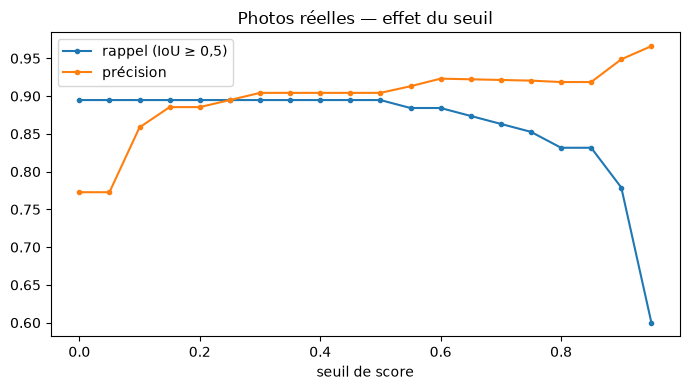

FP (score ≥ 0,3) sur les 4 photos sans plaque : 1


In [4]:
points = courbe_precision_rappel(preds, verites, seuil_iou=0.5)
seuils, rappels, precisions = zip(*points)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(seuils, rappels, marker=".", label="rappel (IoU ≥ 0,5)")
ax.plot(seuils, precisions, marker=".", label="précision")
ax.set_xlabel("seuil de score"); ax.legend(); ax.set_title("Photos réelles — effet du seuil")
plt.tight_layout(); plt.show()

sans_plaque = [i for i, v in enumerate(verites) if not v]
fp_sans = sum(sum(1 for _, s in preds[i] if s >= 0.3) for i in sans_plaque)
print(f"FP (score ≥ 0,3) sur les {len(sans_plaque)} photos sans plaque : {fp_sans}")

## 4. Contrôle visuel — les plaques ratées d'abord

Vert = vérité, rouge pointillé = prédictions (score ≥ 0,3). On affiche en priorité les photos contenant au moins une plaque ratée (le coût RGPD), puis quelques réussites.

In [5]:
from matplotlib.patches import Rectangle
from PIL import Image
from plaques import apparier

ratees, reussies = [], []
for i, (vs, ps) in enumerate(zip(verites, preds)):
    retenues = [(b, s) for b, s in ps if s >= 0.3]
    _, _, fn = apparier(retenues, vs, seuil_iou=0.5)
    (ratees if fn else reussies).append(i)
montrer = (ratees + reussies)[:12]
print(f"photos avec plaque(s) ratée(s) à IoU 0,5 : {len(ratees)}")

fig, axes = plt.subplots(3, 4, figsize=(15, 12))
for ax, i in zip(axes.flat, montrer):
    ax.imshow(Image.open(exemples[i]["image"]))
    for b in verites[i]:
        ax.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                               fill=False, edgecolor="lime", linewidth=2))
    for b, s in preds[i]:
        if s >= 0.3:
            ax.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                               fill=False, edgecolor="red", linewidth=1.2, linestyle="--"))
    ax.set_title(("RATÉE — " if i in ratees else "") + exemples[i]["image"].name, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Résumé chiffré — STOP validation utilisateur

Ces chiffres alimentent l'ADR DL 0002 : verdict de transfert et choix du seuil de floutage. Gate du plan : rappel < ~0,80 au seuil bas → options à trancher (fine-tuning sur une moitié du lot français, ou dataset complémentaire).

In [6]:
r_int = {"rappel": 0.876, "precision": 0.904}  # carnet 02, seuil 0,3, IoU 0,5
r_reel = evaluer(preds, verites, seuil_iou=0.5, seuil_score=0.3)
r_reel_03 = evaluer(preds, verites, seuil_iou=0.3, seuil_score=0.3)
c = bilan_couverture(0.3)
print("=== TRANSFERT — 87 photos perso françaises (95 plaques) ===")
print(f"Rappel  interne (Kaggle) : {r_int['rappel']:.3f}  |  réel : {r_reel['rappel']:.3f} (IoU 0,5)"
      f"  |  réel IoU 0,3 : {r_reel_03['rappel']:.3f}")
print(f"Précision réelle : {r_reel['precision']:.3f} | FN : {r_reel['FN']} plaques ratées")
print(f"Couverture (marge 15 %, seuil 0,3) : moyenne {c['couverture_moyenne']:.1%}, "
      f"≥99 % : {c['couvertes_99']:.1%}, zéro flou : {c['zero']:.1%}")

=== TRANSFERT — 87 photos perso françaises (95 plaques) ===
Rappel  interne (Kaggle) : 0.876  |  réel : 0.895 (IoU 0,5)  |  réel IoU 0,3 : 0.958
Précision réelle : 0.904 | FN : 10 plaques ratées
Couverture (marge 15 %, seuil 0,3) : moyenne 95.3%, ≥99 % : 91.6%, zéro flou : 4.2%
